# Clustering Online Retail Sales Data

Dataset: https://archive.ics.uci.edu/ml/datasets/online+retail

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing, metrics, cluster

%matplotlib inline

Load data

In [2]:
df = pd.read_excel("~/data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Find out if there are any nan in the columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.isna().any()

InvoiceNo      False
StockCode      False
Description     True
Quantity       False
InvoiceDate    False
UnitPrice      False
CustomerID      True
Country        False
dtype: bool

Drop all records having nan CustomerId

In [5]:
df = df[~df.CustomerID.isna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


Find number of unique values for each column

In [6]:
df.nunique()

InvoiceNo      22190
StockCode       3684
Description     3896
Quantity         436
InvoiceDate    20460
UnitPrice        620
CustomerID      4372
Country           37
dtype: int64

Use describe to find range of each column

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


We see quantity column has a large negative value. Probably negative values are not valid for this analysis. Drop the records having negative values in frequency. Verify that there is not more nagative values in the columns

In [8]:
df = df[df.Quantity>0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [10]:
#df = pd.read_excel("~/data/Online Retail.xlsx")
df = df[(df.Quantity>0) & (~df.CustomerID.isna())]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [11]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Convert the InvoiceDate to datetime.

In [13]:
df.InvoiceDate = pd.to_datetime(df.InvoiceDate)

In [14]:
df.InvoiceDate.min(), df.InvoiceDate.max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Create caculated field to computee TotalPrice 

In [16]:
df["TotalPrice"] = df.Quantity * df.UnitPrice
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [17]:
df["TotalPrice"].mean()

22.39474850474768

For calculating rececency, use max for InvoiceDate as point of reference. 

In [18]:
last_date = df.InvoiceDate.max()
last_date

Timestamp('2011-12-09 12:50:00')

Calculate the R-F-M.

In [94]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda values: (last_date - values.max()).days,
    "InvoiceNo" : lambda values: len(values),
    "TotalPrice": lambda values: np.sum(values)
})

rfm.head()


,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


Rename the columns - "recency", "frequency", "monetary"

In [95]:
rfm.columns = ["recency", "frequency", "monetary"]
rfm.head()

,recency,frequency,monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


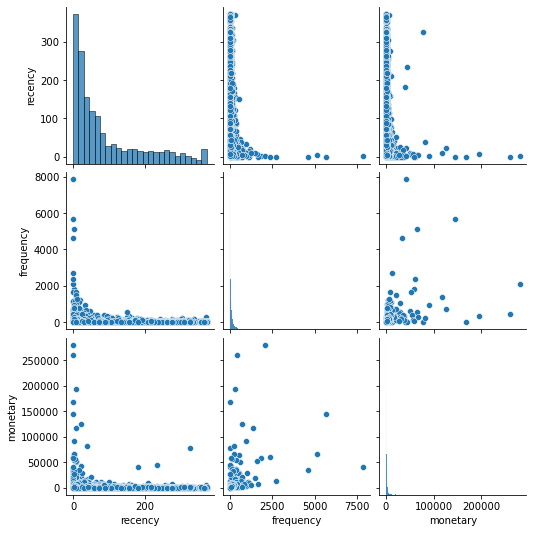

In [102]:
sns.pairplot(rfm)

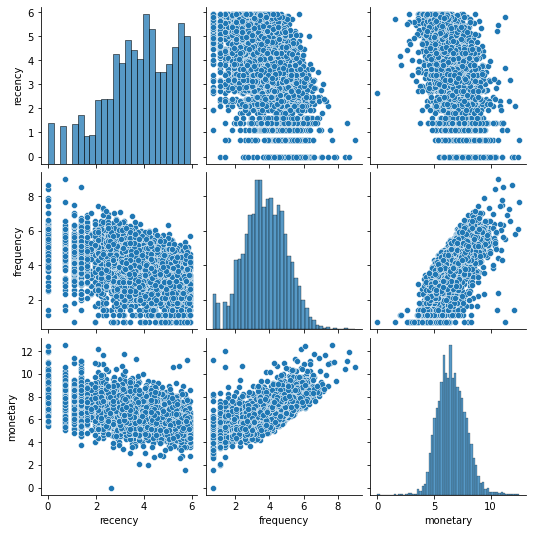

In [101]:
sns.pairplot(pd.DataFrame(np.log(rfm.values + 1), columns = rfm.columns))

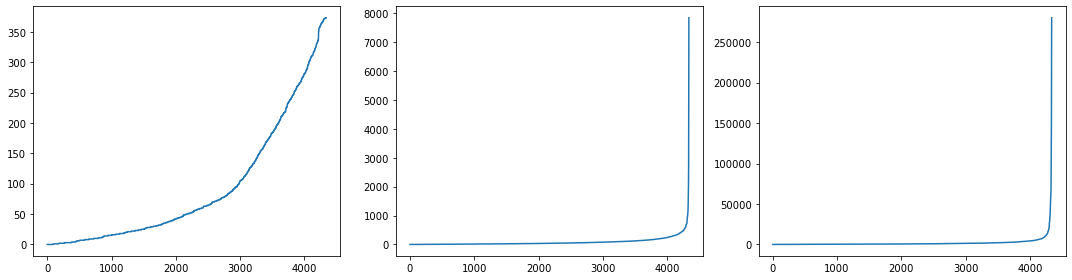

In [108]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

r = np.sort(rfm.recency)
axes[0].plot(np.arange(len(r)), r)
f = np.sort(rfm.frequency)
axes[1].plot(np.arange(len(f)), f)
m = np.sort(rfm.monetary)
axes[2].plot(np.arange(len(m)), m)

plt.tight_layout()

Digitize the columns for R-F-M into 5 equal buckets. To achieve this, find percentile values as bucket boundaries. These will create 5 buckets of equal sizes.

In [21]:
quantiles = np.arange(1, 6) * 20
quantiles

array([ 20,  40,  60,  80, 100])

In [22]:
np.percentile(rfm.recency, quantiles)

array([ 12.6,  32. ,  71. , 178. , 373. ])

In [24]:
np.digitize(rfm.recency, bins = np.percentile(rfm.recency, quantiles), right=True)

array([4, 0, 3, ..., 0, 0, 2])

In [25]:
# Bucketize each of RFM based on the percentile values 

rfm["r_score"] = np.digitize(rfm.recency, bins = np.percentile(rfm.recency, quantiles)
                           , right=True)

rfm["m_score"] = np.digitize(rfm.monetary, bins = np.percentile(rfm.monetary, quantiles)
                           , right=True)

rfm["f_score"] = np.digitize(rfm.frequency, bins = np.percentile(rfm.frequency, quantiles)
                           , right=True)

rfm["r_score"] = 4 - rfm["r_score"]

rfm["r_score"] = rfm["r_score"] + 1
rfm["f_score"] = rfm["f_score"] + 1
rfm["m_score"] = rfm["m_score"] + 1


rfm.head()

,recency,frequency,monetary,r_score,m_score,f_score
CustomerID,,,,,,
12346.0,325,1,77183.60,1,5,1
12347.0,1,182,4310.00,5,5,5
12348.0,74,31,1797.24,2,4,3
12349.0,18,73,1757.55,4,4,4
12350.0,309,17,334.40,1,2,2


In [26]:
rfm.query("r_score == 1 and m_score == 1 and f_score == 1")

,recency,frequency,monetary,r_score,m_score,f_score
CustomerID,,,,,,
12353.0,203,4,89.00,1,1,1
12361.0,286,10,189.90,1,1,1
12401.0,302,5,84.30,1,1,1
12402.0,322,11,225.60,1,1,1
12441.0,366,11,173.55,1,1,1
...,...,...,...,...,...,...
18224.0,263,10,158.95,1,1,1
18227.0,217,5,93.75,1,1,1
18269.0,365,7,168.60,1,1,1


In [28]:
rfm.query("m_score == 1 and f_score == 4")

,recency,frequency,monetary,r_score,m_score,f_score
CustomerID,,,,,,
13271.0,36,96,217.38,3,1,4
13428.0,9,74,218.47,5,1,4
13474.0,235,64,229.59,1,1,4
13532.0,33,66,210.31,3,1,4
14087.0,2,69,194.42,5,1,4
14801.0,60,59,193.14,3,1,4
14995.0,38,61,233.23,3,1,4
15041.0,169,67,180.35,2,1,4
15483.0,160,88,233.81,2,1,4


In [29]:
rfm.sample(10, random_state=123)

,recency,frequency,monetary,r_score,m_score,f_score
CustomerID,,,,,,
13037.0,137,48,881.07,2,3,3
15864.0,21,20,1936.32,4,4,2
13848.0,91,5,1255.00,2,4,1
15274.0,3,47,716.57,5,3,3
17865.0,30,370,10526.32,4,5,5
17398.0,114,38,653.38,2,3,3
12945.0,287,23,462.95,1,2,2
16737.0,52,1,417.60,3,2,1
14796.0,0,1141,8022.49,5,5,5


In [30]:
scaler = preprocessing.StandardScaler()
X = rfm[["r_score", "f_score", "m_score"]].values
X = scaler.fit_transform(X.astype("float32"))
X

array([[-1.4252185 , -1.3840665 ,  1.4140506 ],
       [ 1.4030564 ,  1.4140533 ,  1.4140506 ],
       [-0.7181498 ,  0.01499338,  0.7070253 ],
       ...,
       [ 1.4030564 , -1.3840665 , -1.4140506 ],
       [ 1.4030564 ,  1.4140533 ,  1.4140506 ],
       [-0.01108105,  0.7145233 ,  0.7070253 ]], dtype=float32)

Find what could be an optimal number of clusters using elbow plot. As we see in the plot below, we can use 5 or 6 number of clusters (K) for KMeans algorithm.

Text(0, 0.5, 'Inertia Score')

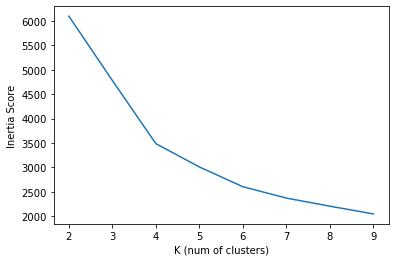

In [31]:
inertias = {}
for k in range(2, 10): 
    kmeans = cluster.KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertias[k] = kmeans.inertia_
    
pd.Series(inertias).plot()
plt.xlabel("K (num of clusters)")
plt.ylabel("Inertia Score")

In [32]:
# Model training
k = 5
kmeans = cluster.KMeans(n_clusters=k, random_state = 1)
rfm["cluster"] = kmeans.fit_predict(X)

In [33]:
rfm.cluster.value_counts()

0    1136
1    1087
4     853
2     668
3     595
Name: cluster, dtype: int64

In [34]:
rfm["distance"] = 0.0
for i in range(k):
    centroid = kmeans.cluster_centers_[i].reshape(1, -1)
    cluster_points = X[rfm.cluster == i]
    rfm["distance"][rfm.cluster == i] = metrics.euclidean_distances(centroid, cluster_points).flatten()
rfm.sample(20)

<ipython-input-34-20d85d148ded>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm["distance"][rfm.cluster == i] = metrics.euclidean_distances(centroid, cluster_points).flatten()
<ipython-input-34-20d85d148ded>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm["distance"][rfm.cluster == i] = metrics.euclidean_distances(centroid, cluster_points).flatten()
<ipython-input-34-20d85d148ded>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-cop

,recency,frequency,monetary,r_score,m_score,f_score,cluster,distance
CustomerID,,,,,,,,
16174.0,125,23,1009.55,2,4,2,4,1.204237
13416.0,43,19,712.50,3,3,2,2,0.973407
14205.0,16,24,466.70,4,2,2,3,0.501610
14657.0,17,126,848.22,4,3,5,1,1.200729
14114.0,273,15,386.53,1,2,2,0,0.456777
12409.0,78,109,11072.67,2,5,4,4,0.914087
12821.0,213,6,92.72,1,1,1,0,0.692689
14177.0,85,42,559.41,2,3,3,4,0.726112
14368.0,319,8,155.00,1,1,1,0,0.692689


In [35]:
rfm.groupby("cluster").distance.agg(["mean", "count"])

,mean,count
cluster,,
0,0.755233,1136
1,0.673123,1087
2,0.835333,668
3,0.773771,595
4,0.892773,853


In [37]:
X = rfm[["recency","frequency","monetary"]]
X

,recency,frequency,monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40
...,...,...,...
18280.0,277,10,180.60
18281.0,180,7,80.82
18282.0,7,12,178.05


In [38]:
X.shape

(4339, 3)

In [56]:
X.describe()

,recency,frequency,monetary
count,4339.000000,4339.000000,4339.000000
mean,91.518322,91.708689,2053.793018
std,100.009747,228.792852,8988.248381
min,0.000000,1.000000,0.000000
25%,17.000000,17.000000,307.245000
50%,50.000000,41.000000,674.450000
75%,141.000000,100.000000,1661.640000
max,373.000000,7847.000000,280206.020000


In [58]:
X.quantile(q = 0.90)

recency       262.000
frequency     208.000
monetary     3646.164
Name: 0.9, dtype: float64

In [124]:
X_log = np.log(X.values + 1)
pd.DataFrame(X_log).describe()

,0,1,2
count,4339.000000,4339.000000,4339.000000
mean,3.767274,3.736603,6.592108
std,1.432382,1.251139,1.261411
min,0.000000,0.693147,0.000000
25%,2.890372,2.890372,5.730895
50%,3.931826,3.737670,6.515379
75%,4.955827,4.615121,7.416162
max,5.924256,8.968014,12.543284


In [43]:
X_std = preprocessing.StandardScaler().fit_transform(X_log)

# Local Outlier Factor (LOF) anomaly detection

In [259]:
from sklearn import neighbors
lof = neighbors.LocalOutlierFactor(n_neighbors=20)
outliers = lof.fit_predict(X_std)
pd.Series(outliers).value_counts()

 1    4300
-1      39
dtype: int64

In [260]:
sum(outliers == -1)/len(outliers) * 100

0.8988246139663517

In [261]:
X_log[outliers == -1]

array([[ 5.78689738,  0.69314718, 11.25395523],
       [ 0.        ,  8.4331592 , 10.42586806],
       [ 2.30258509,  2.19722458,  8.85052335],
       [ 5.04985601,  2.30258509,  3.69486153],
       [ 2.48490665,  6.93634274, 10.25197235],
       [ 5.62040087,  5.07517382,  8.96616086],
       [ 5.28320373,  0.69314718,  8.03818918],
       [ 1.09861229,  3.49650756,  8.77413354],
       [ 2.63905733,  0.69314718,  0.        ],
       [ 0.        ,  7.42535789,  8.91664962],
       [ 0.        ,  1.09861229,  5.88887796],
       [ 5.65599181,  3.4339872 ,  4.22288435],
       [ 1.38629436,  8.539346  , 11.08468992],
       [ 2.07944154,  7.40123126, 10.84988645],
       [ 0.        ,  7.90137735,  9.40571388],
       [ 4.15888308,  1.09861229,  1.97408103],
       [ 0.        ,  8.64435434, 11.87635993],
       [ 5.53338949,  2.56494936,  4.08580823],
       [ 5.54517744,  3.97029191,  8.50918118],
       [ 2.30258509,  7.31521839,  9.89925059],
       [ 5.20400669,  1.38629436, 10.594

<AxesSubplot:>

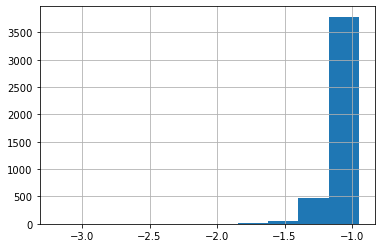

In [262]:
pd.Series(lof.negative_outlier_factor_).hist()

In [263]:
sum(pd.Series(lof.negative_outlier_factor_)<-1.5) # Default offset for detecting the outliers

39

In [258]:
def show_outliers(X, outliers, title = None):
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize = (15, 15))
    ax = fig.add_subplot(111, projection='3d')
    colors = np.where(outliers, "red", "lightgray")
    ax.scatter(X[:,0], X[:,1], X[:,2], color = colors, alpha = 0.8)
    ax.set_xlabel("recency (log)")
    ax.set_ylabel("frequency (log)")
    ax.set_zlabel("monetary (log)")
    if title is not None:
        ax.set_title(title)

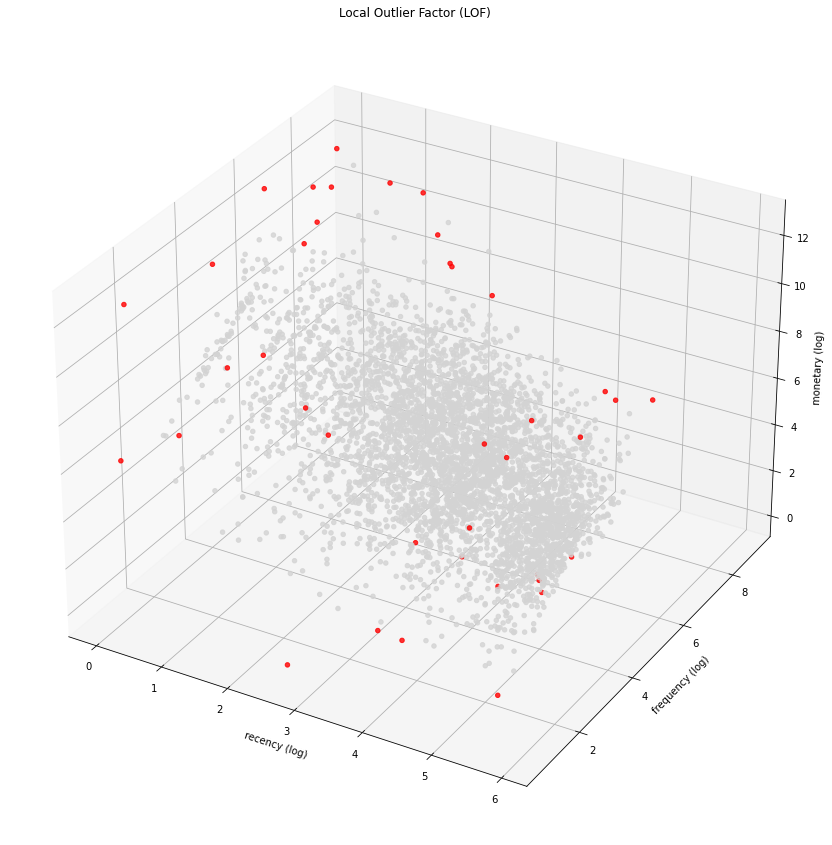

In [266]:
show_outliers(X_log, outliers==-1, "Local Outlier Factor (LOF)")

# Isolation Forest

In [1]:
#from pyod.models.iforest import IForest
from sklearn.ensemble import IsolationForest
iforest = IsolationForest(n_estimators=200, contamination="auto")
iforest.fit(X)
outliers = iforest.predict(X)
pd.Series(outliers).value_counts()

NameError: name 'X' is not defined

In [311]:
sum(outliers == -1)/len(outliers) * 100

12.65268495044941

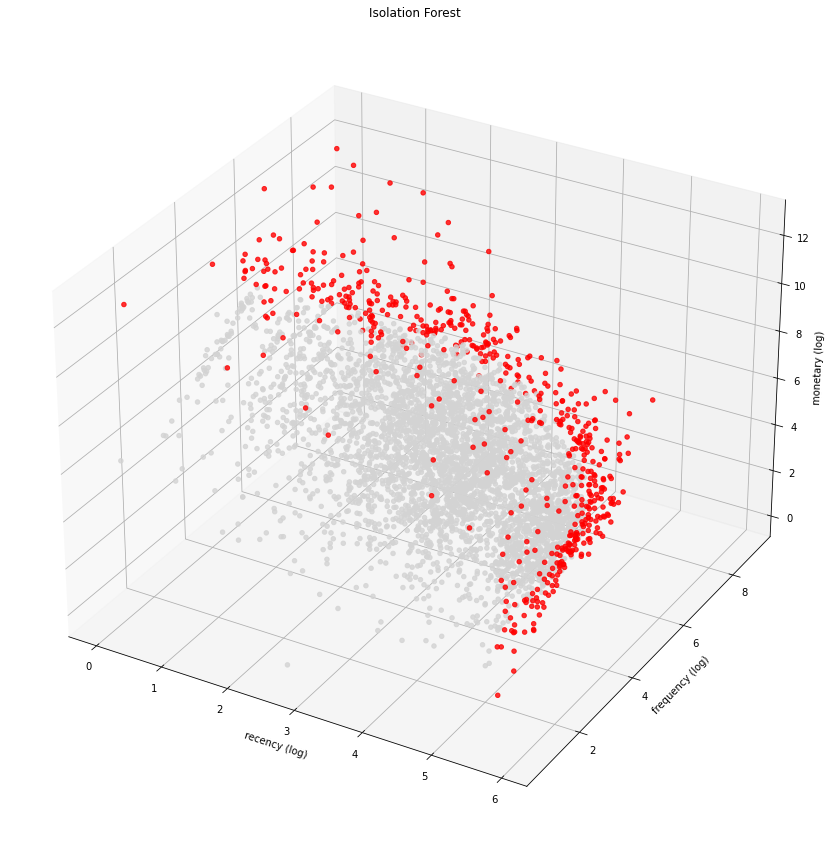

In [312]:
show_outliers(X_log, outliers==-1, "Isolation Forest")

In [313]:
iforest.offset_

-0.5

# CBLOF

In [150]:
from pyod.models.cblof import CBLOF

In [272]:
cdlof = CBLOF(contamination=0.01, check_estimator=False, random_state=0, alpha=0.8, beta=5, n_clusters = 8)
"""
Number of K-mean clusters = 8
alpha and beta distinguishes small and large cluster
Cluster is large cluster if,

comulative size(cluster)> 0.8 * total record count 
    or 
it is bigger than next cluster in size by factor of 5
"""

cdlof.fit(X_std)
outliers = cdlof.predict(X_std)
pd.Series(outliers).value_counts()

/Users/abasar/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:938: FutureWarning:

'n_jobs' was deprecated in version 0.23 and will be removed in 0.25.



0    4295
1      44
dtype: int64

In [273]:
cdlof

CBLOF(alpha=0.8, beta=5, check_estimator=False, clustering_estimator=None,
   contamination=0.01, n_clusters=8, n_jobs=1, random_state=0,
   use_weights=False)

In [274]:
cdlof.cluster_sizes_

array([682, 646, 856, 452, 272, 603, 363, 465])

In [278]:
cdlof.decision_scores_

array([4.34285952, 1.83922733, 0.64463366, ..., 0.80342021, 1.81983377,
       0.7467928 ])

In [281]:
cdlof.large_cluster_labels_, cdlof.small_cluster_labels_

(array([2, 0, 1, 5, 7, 3]), array([6, 4]))

In [282]:
cdlof.threshold_

2.6478507433722918

In [153]:
pd.Series(outliers).value_counts() / len(outliers) * 100

0    98.985941
1     1.014059
dtype: float64

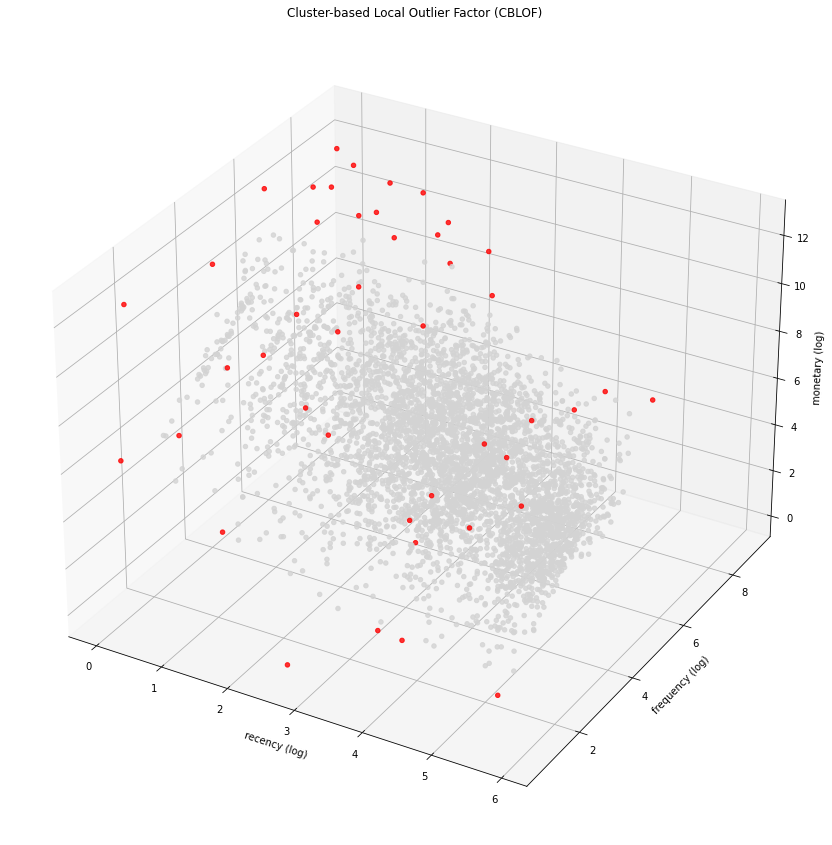

In [248]:
show_outliers(X_log, outliers == 1, "Cluster-based Local Outlier Factor (CBLOF)")

In [283]:
from pyod.models.hbos import HBOS

In [284]:
hbos = HBOS(n_bins=10, alpha=0.1, tol=0.5, contamination=0.01)
hbos.fit(X_log)
outliers = hbos.predict(X_log)
pd.Series(outliers).value_counts()

0    4301
1      38
dtype: int64

In [285]:
pd.Series(outliers).value_counts() / len(outliers) * 100

0    99.124222
1     0.875778
dtype: float64

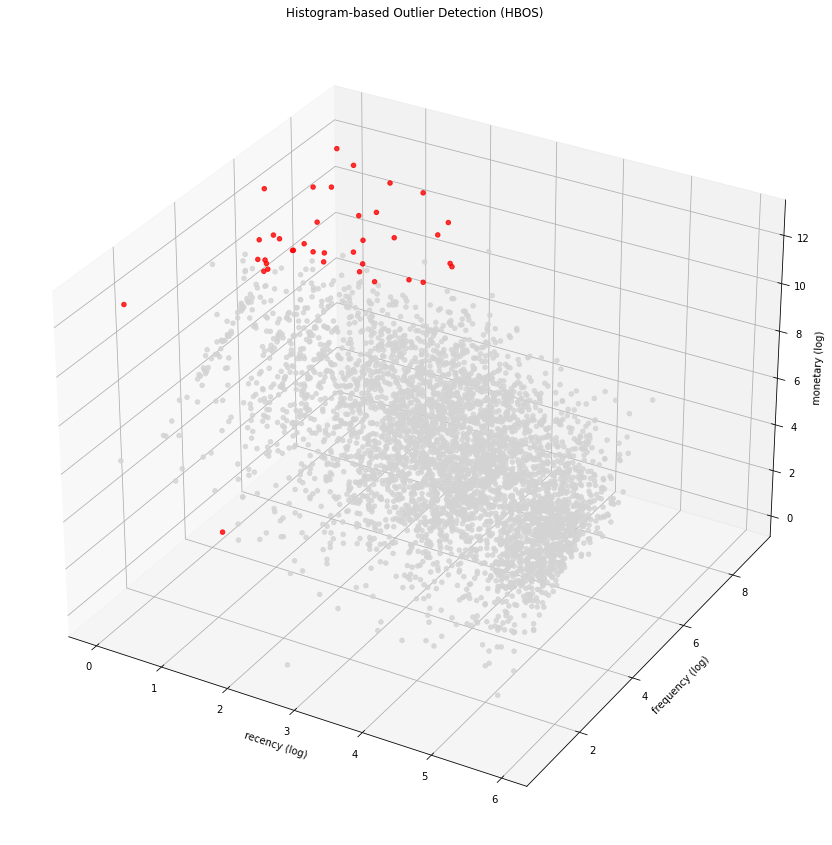

In [286]:
show_outliers(X_log, outliers == 1, "Histogram-based Outlier Detection (HBOS)")

In [288]:
hbos.decision_scores_, hbos.threshold_

(array([7.38716839, 6.54678763, 4.1672225 , ..., 5.3400093 , 7.79930484,
        4.30713567]),
 8.194320353186974)

In [292]:
hbos.bin_edges_ # Note: the bins are of equal width e.g. static histogram

array([[ 0.        ,  0.69314718,  0.        ],
       [ 0.59242558,  1.52063386,  1.2543284 ],
       [ 1.18485116,  2.34812054,  2.50865679],
       [ 1.77727674,  3.17560723,  3.76298519],
       [ 2.36970232,  4.00309391,  5.01731359],
       [ 2.9621279 ,  4.83058059,  6.27164198],
       [ 3.55455348,  5.65806727,  7.52597038],
       [ 4.14697906,  6.48555396,  8.78029878],
       [ 4.73940464,  7.31304064, 10.03462717],
       [ 5.33183022,  8.14052732, 11.28895557],
       [ 5.9242558 ,  8.968014  , 12.54328397]])

In [293]:
1.18485116 - 0.59242558, 1.77727674- 1.18485116, 5.9242558-5.33183022

(0.59242558, 0.59242558, 0.5924255800000005)

In [167]:
from pyod.models.knn import KNN

In [168]:
knn = KNN(contamination=0.01)
hbos.fit(X_std)
outliers = hbos.predict(X_std)
pd.Series(outliers).value_counts()

0    4301
1      38
dtype: int64

In [169]:
pd.Series(outliers).value_counts() / len(outliers) * 100

0    99.124222
1     0.875778
dtype: float64

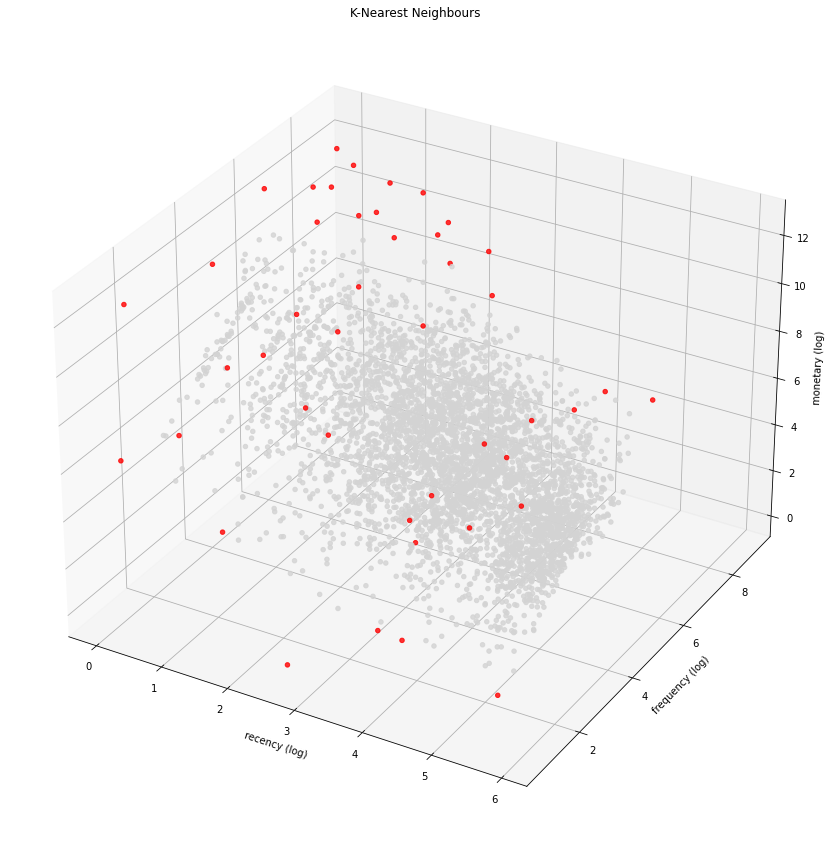

In [246]:
show_outliers(X_log, outliers == 1, title="K-Nearest Neighbours")

In [242]:
from pyod.models.abod import ABOD

In [243]:
abod = ABOD(contamination=0.01, n_neighbors=20)
abod.fit(X_std)
outliers = abod.predict(X_std)
pd.Series(outliers).value_counts()

0    4295
1      44
dtype: int64

In [244]:
pd.Series(outliers).value_counts() / len(outliers) * 100

0    98.985941
1     1.014059
dtype: float64

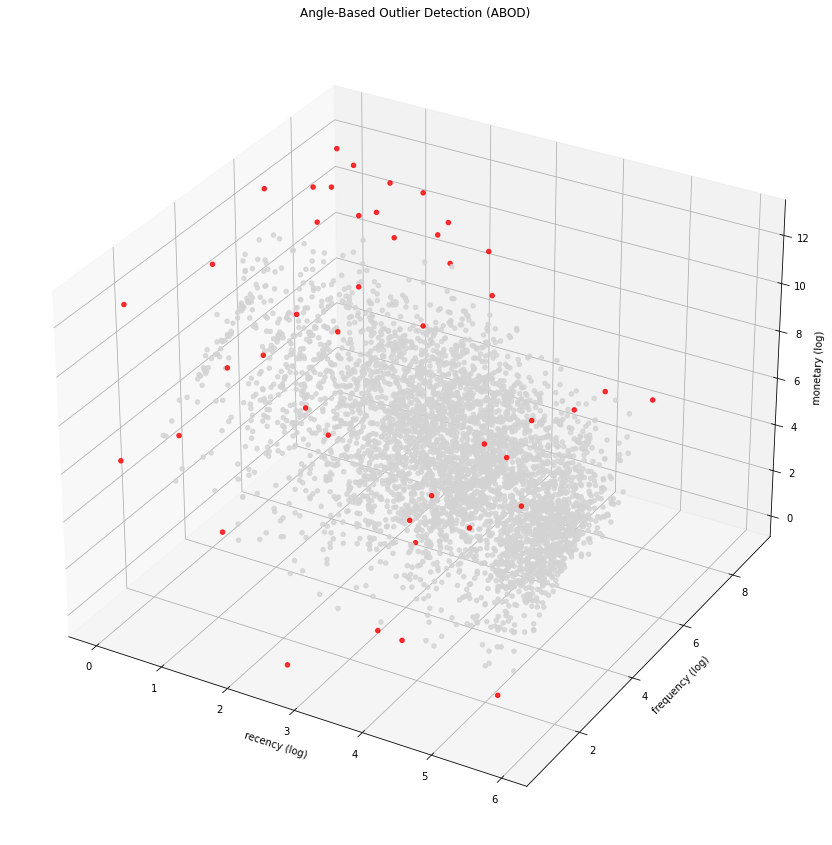

In [245]:
show_outliers(X_log, outliers == 1, "Angle-Based Outlier Detection (ABOD)")

In [180]:
from pyod.models.loci import LOCI

In [267]:
loci = LOCI(contamination=0.01, alpha=0.5, k=3)
loci.fit(X_std)
outliers = loci.predict(X_std)
pd.Series(outliers).value_counts()

KeyboardInterrupt: 

# Outlier Detection using Mahalanobis Distance

In [192]:
X_mean = X_std.mean(axis = 0)
X_mean

array([-1.98146280e-16, -1.17086438e-16,  1.57206966e-16])

In [200]:
S_inv = np.linalg.inv(np.cov(X_std.T)) 
# The argument matrix of np.cov contains records column wise, hence transposing data 
S_inv.shape
# Validate that S_inv must be a square matrix,
# number of rows/columns = number of features, and 
# positive semi definite (non-negative Eigen values)

(3, 3)

In [204]:
np.linalg.eigvals(S_inv)

array([0.46080431, 1.68092538, 4.24335539])

In [211]:
from scipy.spatial.distance import mahalanobis
row_count = len(X_std)
X_mahalanobis_distance = np.zeros(row_count)
for i in range(row_count):
    X_mahalanobis_distance[i] = mahalanobis(X_std[i], X_mean, S_inv)
X_mahalanobis_distance

array([9.1507371 , 2.1989112 , 1.50241174, ..., 2.32370504, 2.86706479,
       0.84453482])

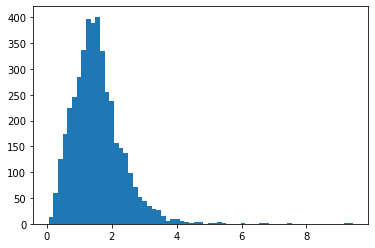

In [212]:
plt.hist(X_mahalanobis_distance, bins = int(row_count ** 0.5));

In [238]:
outliers = X_mahalanobis_distance > 4.0 
# statistically we can determine this threshold using Chisquare test
sum(outliers)

34

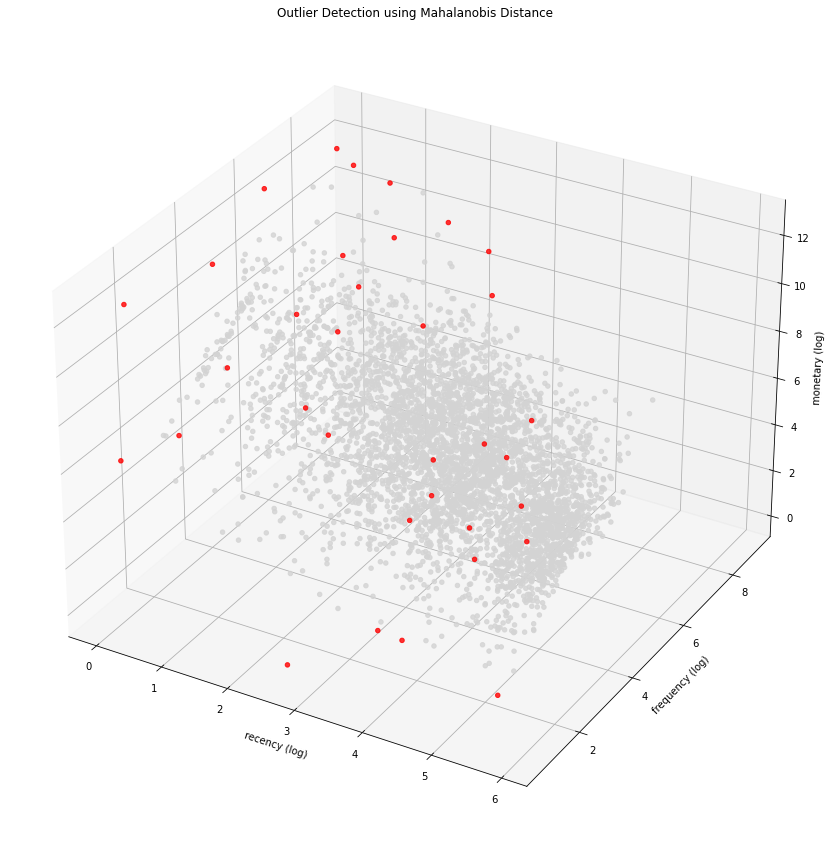

In [241]:
show_outliers(X_log, outliers, "Outlier Detection using Mahalanobis Distance")